In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import html

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
# Load Marc's TTRPG dataset
ttrpg_df = pd.read_csv("../marc/ttrpg_database_final.csv")

# Load board game dataset
boardgame_df = pd.read_csv("../q/shortened_dataset.csv")

print("TTRPG shape:", ttrpg_df.shape)
print("TTRPG columns:", ttrpg_df.columns.tolist())

print("\nBoard game shape:", boardgame_df.shape)
print("Board game columns:", boardgame_df.columns.tolist())

display(ttrpg_df.head())
display(boardgame_df.head())

TTRPG shape: (6353, 5)
TTRPG columns: ['Name', 'Description', 'Average Score', 'Number of Reviews', 'Publishing Year']

Board game shape: (10000, 4)
Board game columns: ['Unnamed: 0', 'name', 'description', 'Average']


,Name,Description,Average Score,Number of Reviews,Publishing Year
0,The Strange,Publisher Blurb: Beneath the orbits and atoms ...,7.86486,37,NaN
1,InSpectres,Fighting the Forces of Darkness so you don't h...,7.57355,138,NaN
2,Dungeons & Dragons Expert Set,The first version of the D&D Expert Set. It co...,7.97881,151,NaN
3,The Character Compendium,An unofficial supplement for Warhammer Fantasy...,8.09375,16,NaN
4,The Elves of Alfheim,"""This is the first Gazetteer to outline a non-...",7.24878,41,NaN


,Unnamed: 0,name,description,Average
0,0,Pandemic,"In Pandemic, several virulent diseases have br...",7.59
1,1,Carcassonne,Carcassonne is a tile-placement game in which ...,7.42
2,2,Catan,"In CATAN (formerly The Settlers of Catan), pla...",7.14
3,3,7 Wonders,You are the leader of one of the 7 great citie...,7.74
4,4,Dominion,"&quot;You are a monarch, like your parents bef...",7.61


In [3]:
ttrpg_clean = ttrpg_df.rename(columns={
    "Name": "title",
    "Description": "description",
    "Average Score": "average_score",
    "Number of Reviews": "number_of_reviews"
}).copy()

ttrpg_clean["type"] = "TTRPG"

ttrpg_clean = ttrpg_clean[[
    "title",
    "description",
    "average_score",
    "number_of_reviews",
    "type"
]]

ttrpg_clean.head()

,title,description,average_score,number_of_reviews,type
0,The Strange,Publisher Blurb: Beneath the orbits and atoms ...,7.86486,37,TTRPG
1,InSpectres,Fighting the Forces of Darkness so you don't h...,7.57355,138,TTRPG
2,Dungeons & Dragons Expert Set,The first version of the D&D Expert Set. It co...,7.97881,151,TTRPG
3,The Character Compendium,An unofficial supplement for Warhammer Fantasy...,8.09375,16,TTRPG
4,The Elves of Alfheim,"""This is the first Gazetteer to outline a non-...",7.24878,41,TTRPG


In [4]:
boardgame_clean = boardgame_df.rename(columns={
    "name": "title",
    "description": "description",
    "Average": "average_score"
}).copy()

# Board game dataset does not have number of reviews
boardgame_clean["number_of_reviews"] = np.nan

boardgame_clean["type"] = "Board Game"

boardgame_clean = boardgame_clean[[
    "title",
    "description",
    "average_score",
    "number_of_reviews",
    "type"
]]

boardgame_clean.head()

,title,description,average_score,number_of_reviews,type
0,Pandemic,"In Pandemic, several virulent diseases have br...",7.59,NaN,Board Game
1,Carcassonne,Carcassonne is a tile-placement game in which ...,7.42,NaN,Board Game
2,Catan,"In CATAN (formerly The Settlers of Catan), pla...",7.14,NaN,Board Game
3,7 Wonders,You are the leader of one of the 7 great citie...,7.74,NaN,Board Game
4,Dominion,"&quot;You are a monarch, like your parents bef...",7.61,NaN,Board Game


In [5]:
# merge datasets inside notebook

combined_df = pd.concat(
    [ttrpg_clean, boardgame_clean],
    ignore_index=True
)

# Remove rows without usable text
combined_df = combined_df.dropna(subset=["title", "description"]).copy()

combined_df["title"] = combined_df["title"].astype(str)
combined_df["description"] = combined_df["description"].astype(str)

combined_df = combined_df[combined_df["description"].str.strip() != ""].copy()

combined_df["average_score"] = pd.to_numeric(
    combined_df["average_score"],
    errors="coerce"
)

combined_df["number_of_reviews"] = pd.to_numeric(
    combined_df["number_of_reviews"],
    errors="coerce"
)

# Remove duplicate titles within each type
combined_df = combined_df.drop_duplicates(subset=["title", "type"]).reset_index(drop=True)

print("Combined shape:", combined_df.shape)
print(combined_df["type"].value_counts())

combined_df.head()

Combined shape: (15165, 5)
type
Board Game    8976
TTRPG         6189
Name: count, dtype: int64


,title,description,average_score,number_of_reviews,type
0,The Strange,Publisher Blurb: Beneath the orbits and atoms ...,7.86486,37.0,TTRPG
1,InSpectres,Fighting the Forces of Darkness so you don't h...,7.57355,138.0,TTRPG
2,Dungeons & Dragons Expert Set,The first version of the D&D Expert Set. It co...,7.97881,151.0,TTRPG
3,The Character Compendium,An unofficial supplement for Warhammer Fantasy...,8.09375,16.0,TTRPG
4,The Elves of Alfheim,"""This is the first Gazetteer to outline a non-...",7.24878,41.0,TTRPG


In [6]:
# check what wa removed

print("Original board games:", boardgame_clean.shape)
print("Board games missing description:", boardgame_clean["description"].isna().sum())
print("Board games empty description:", (boardgame_clean["description"].astype(str).str.strip() == "").sum())
print("Board game duplicate title/type:", boardgame_clean.duplicated(subset=["title", "type"]).sum())

print("\nOriginal TTRPGs:", ttrpg_clean.shape)
print("TTRPGs missing description:", ttrpg_clean["description"].isna().sum())
print("TTRPGs empty description:", (ttrpg_clean["description"].astype(str).str.strip() == "").sum())
print("TTRPG duplicate title/type:", ttrpg_clean.duplicated(subset=["title", "type"]).sum())

Original board games: (10000, 5)
Board games missing description: 0
Board games empty description: 0
Board game duplicate title/type: 1024

Original TTRPGs: (6353, 5)
TTRPGs missing description: 0
TTRPGs empty description: 0
TTRPG duplicate title/type: 164


preprocessing functions

In [7]:
def preprocess_basic(text):
    """
    Basic preprocessing:
    - fixes HTML symbols
    - lowercases text
    - removes non-letter characters
    - removes extra spaces
    """
    text = html.unescape(str(text))
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def preprocess_no_short_words(text):
    """
    Basic preprocessing + removes words with 2 characters or fewer.
    """
    text = preprocess_basic(text)
    words = text.split()
    words = [word for word in words if len(word) > 2]
    return " ".join(words)


def preprocess_remove_game_words(text):
    """
    Removes common game-related words that may be too repetitive.
    """
    text = preprocess_no_short_words(text)

    custom_stopwords = {
        "game", "games", "role", "playing", "player", "players",
        "character", "characters", "rule", "rules", "system",
        "board", "card", "cards", "dice", "play"
    }

    words = text.split()
    words = [word for word in words if word not in custom_stopwords]
    return " ".join(words)

In [8]:
# apply preprocessing

combined_df["text_basic"] = combined_df["description"].apply(preprocess_basic)
combined_df["text_no_short"] = combined_df["description"].apply(preprocess_no_short_words)
combined_df["text_custom_stopwords"] = combined_df["description"].apply(preprocess_remove_game_words)

combined_df[["title", "type", "text_basic", "text_no_short", "text_custom_stopwords"]].head()

,title,type,text_basic,text_no_short,text_custom_stopwords
0,The Strange,TTRPG,publisher blurb beneath the orbits and atoms o...,publisher blurb beneath the orbits and atoms o...,publisher blurb beneath the orbits and atoms o...
1,InSpectres,TTRPG,fighting the forces of darkness so you don t h...,fighting the forces darkness you don have insp...,fighting the forces darkness you don have insp...
2,Dungeons & Dragons Expert Set,TTRPG,the first version of the d d expert set it con...,the first version the expert set contains page...,the first version the expert set contains page...
3,The Character Compendium,TTRPG,an unofficial supplement for warhammer fantasy...,unofficial supplement for warhammer fantasy ro...,unofficial supplement for warhammer fantasy ro...
4,The Elves of Alfheim,TTRPG,this is the first gazetteer to outline a non h...,this the first gazetteer outline non human cul...,this the first gazetteer outline non human cul...


In [9]:
# Use sampled data for faster experimentation
# This keeps the experiment manageable while still including both TTRPGs and board games.

sample_size = min(5000, len(combined_df))

sampled_df = combined_df.sample(
    n=sample_size,
    random_state=42
).reset_index(drop=True)

print("Sampled shape:", sampled_df.shape)
print(sampled_df["type"].value_counts())

sampled_df.head()

Sampled shape: (5000, 8)
type
Board Game    2968
TTRPG         2032
Name: count, dtype: int64


,title,description,average_score,number_of_reviews,type,text_basic,text_no_short,text_custom_stopwords
0,Escape from Innsmouth (1st Edition),"From the back of the book: ""Innsmouth was once...",7.9375,8.0,TTRPG,from the back of the book innsmouth was once a...,from the back the book innsmouth was once pros...,from the back the book innsmouth was once pros...
1,Ace of Aces: Handy Rotary Deluxe Edition,The Handy Rotary Deluxe edition was a revision...,7.1000,NaN,Board Game,the handy rotary deluxe edition was a revision...,the handy rotary deluxe edition was revision t...,the handy rotary deluxe edition was revision t...
2,Mister X,He could escape the Scotland Yard detectives i...,6.6300,NaN,Board Game,he could escape the scotland yard detectives i...,could escape the scotland yard detectives lond...,could escape the scotland yard detectives lond...
3,Havens of the Great Bay,"From the back of the box: ""Sunlight glinted of...",7.4000,10.0,TTRPG,from the back of the box sunlight glinted off ...,from the back the box sunlight glinted off the...,from the back the box sunlight glinted off the...
4,Sweden Fights On,Sweden Fights On is a tactical battle game fea...,7.7000,NaN,Board Game,sweden fights on is a tactical battle game fea...,sweden fights tactical battle game featuring f...,sweden fights tactical battle featuring four b...


In [11]:
# svd experiment function
def run_svd_experiment(
    text_data,
    experiment_name,
    max_features=3000,
    min_df=5,
    ngram_range=(1, 1),
    variance_threshold=0.90,
    component_cap=300
):
    """
    Runs TF-IDF + TruncatedSVD on text data.
    Returns experiment results and fitted objects.
    """

    vectorizer = TfidfVectorizer(
        stop_words="english",
        lowercase=True,
        max_features=max_features,
        min_df=min_df,
        ngram_range=ngram_range
    )

    X_tfidf = vectorizer.fit_transform(text_data)

    max_components = min(
        X_tfidf.shape[0] - 1,
        X_tfidf.shape[1] - 1,
        component_cap
    )

    svd = TruncatedSVD(
        n_components=max_components,
        random_state=42,
        n_iter=5
    )

    X_svd = svd.fit_transform(X_tfidf)

    cumulative_variance = svd.explained_variance_ratio_.cumsum()

    reached_threshold = cumulative_variance[-1] >= variance_threshold

    if reached_threshold:
        retained_svs = np.argmax(cumulative_variance >= variance_threshold) + 1
    else:
        retained_svs = max_components

    result = {
        "experiment": experiment_name,
        "max_features": max_features,
        "min_df": min_df,
        "ngram_range": str(ngram_range),
        "tfidf_rows": X_tfidf.shape[0],
        "tfidf_features": X_tfidf.shape[1],
        "components_tested": max_components,
        "reached_90_percent": reached_threshold,
        "retained_svs": retained_svs,
        "explained_variance_at_retained_svs": cumulative_variance[retained_svs - 1],
        "max_explained_variance_tested": cumulative_variance[-1]
    }

    return result, vectorizer, svd, X_tfidf, X_svd, cumulative_variance

run preprocessing experiments on sampled data

In [12]:
experiments = []
saved_outputs = {}

experiment_settings = [
    {
        "experiment_name": "Basic + unigram + 1000 features",
        "text_column": "text_basic",
        "max_features": 1000,
        "min_df": 5,
        "ngram_range": (1, 1)
    },
    {
        "experiment_name": "Basic + unigram + 3000 features",
        "text_column": "text_basic",
        "max_features": 3000,
        "min_df": 5,
        "ngram_range": (1, 1)
    },
    {
        "experiment_name": "No short words + unigram + 3000 features",
        "text_column": "text_no_short",
        "max_features": 3000,
        "min_df": 5,
        "ngram_range": (1, 1)
    },
    {
        "experiment_name": "Custom stopwords + unigram + 3000 features",
        "text_column": "text_custom_stopwords",
        "max_features": 3000,
        "min_df": 5,
        "ngram_range": (1, 1)
    },
    {
        "experiment_name": "Basic + unigram/bigram + 3000 features",
        "text_column": "text_basic",
        "max_features": 3000,
        "min_df": 5,
        "ngram_range": (1, 2)
    }
]

for setting in experiment_settings:
    print("Running:", setting["experiment_name"])

    result, vectorizer, svd, X_tfidf, X_svd, cumulative_variance = run_svd_experiment(
        text_data=sampled_df[setting["text_column"]],
        experiment_name=setting["experiment_name"],
        max_features=setting["max_features"],
        min_df=setting["min_df"],
        ngram_range=setting["ngram_range"],
        component_cap=300
    )

    experiments.append(result)

    saved_outputs[setting["experiment_name"]] = {
        "vectorizer": vectorizer,
        "svd": svd,
        "X_tfidf": X_tfidf,
        "X_svd": X_svd,
        "cumulative_variance": cumulative_variance,
        "text_column": setting["text_column"]
    }

results_df = pd.DataFrame(experiments)

results_df.sort_values(
    by=["reached_90_percent", "retained_svs", "max_explained_variance_tested"],
    ascending=[False, True, False]
)

Running: Basic + unigram + 1000 features
Running: Basic + unigram + 3000 features
Running: No short words + unigram + 3000 features
Running: Custom stopwords + unigram + 3000 features
Running: Basic + unigram/bigram + 3000 features


,experiment,max_features,min_df,ngram_range,tfidf_rows,tfidf_features,components_tested,reached_90_percent,retained_svs,explained_variance_at_retained_svs,max_explained_variance_tested
0,Basic + unigram + 1000 features,1000,5,"(1, 1)",5000,1000,300,False,300,0.611578,0.611578
4,Basic + unigram/bigram + 3000 features,3000,5,"(1, 2)",5000,3000,300,False,300,0.413528,0.413528
2,No short words + unigram + 3000 features,3000,5,"(1, 1)",5000,3000,300,False,300,0.408634,0.408634
1,Basic + unigram + 3000 features,3000,5,"(1, 1)",5000,3000,300,False,300,0.407694,0.407694
3,Custom stopwords + unigram + 3000 features,3000,5,"(1, 1)",5000,3000,300,False,300,0.394327,0.394327


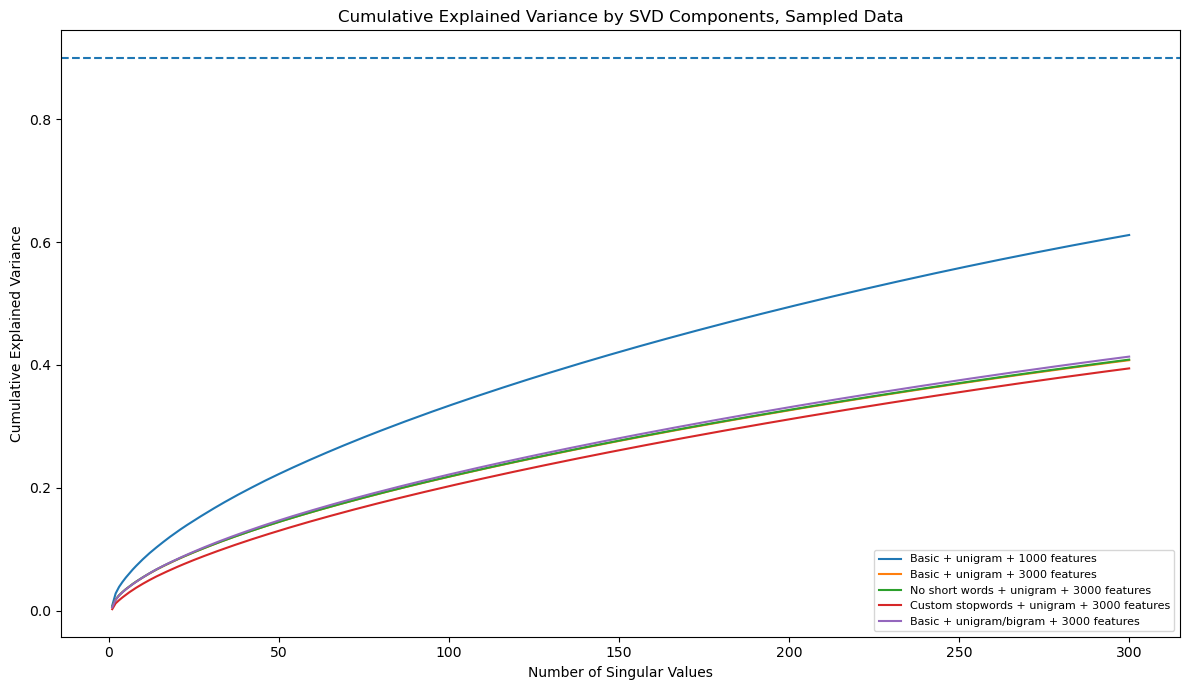

In [13]:
#plot sampled experiment results

plt.figure(figsize=(12, 7))

for experiment_name, output in saved_outputs.items():
    cumulative_variance = output["cumulative_variance"]

    plt.plot(
        range(1, len(cumulative_variance) + 1),
        cumulative_variance,
        label=experiment_name
    )

plt.axhline(0.90, linestyle="--")

plt.title("Cumulative Explained Variance by SVD Components, Sampled Data")
plt.xlabel("Number of Singular Values")
plt.ylabel("Cumulative Explained Variance")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

pick best method for sampled experiments

In [15]:
# If any experiment reaches 90%, choose the one with the fewest retained SVs.
# If none reaches 90%, choose the one with highest explained variance.

if results_df["reached_90_percent"].any():
    best_experiment_name = (
        results_df[results_df["reached_90_percent"] == True]
        .sort_values(by="retained_svs", ascending=True)
        .iloc[0]["experiment"]
    )
else:
    best_experiment_name = (
        results_df
        .sort_values(by="max_explained_variance_tested", ascending=False)
        .iloc[0]["experiment"]
    )

print("Best sampled experiment:", best_experiment_name)

best_sampled_setting = next(
    setting for setting in experiment_settings
    if setting["experiment_name"] == best_experiment_name
)

best_sampled_setting

Best sampled experiment: Basic + unigram + 1000 features


{'experiment_name': 'Basic + unigram + 1000 features',
 'text_column': 'text_basic',
 'max_features': 1000,
 'min_df': 5,
 'ngram_range': (1, 1)}

In [16]:
# Apply the highest-performing sampled method to the full merged dataset.

full_result, full_vectorizer, full_svd, full_X_tfidf, full_X_svd, full_cumvar = run_svd_experiment(
    text_data=combined_df[best_sampled_setting["text_column"]],
    experiment_name=best_sampled_setting["experiment_name"] + " applied to full dataset",
    max_features=best_sampled_setting["max_features"],
    min_df=best_sampled_setting["min_df"],
    ngram_range=best_sampled_setting["ngram_range"],
    component_cap=700
)

full_result

{'experiment': 'Basic + unigram + 1000 features applied to full dataset',
 'max_features': 1000,
 'min_df': 5,
 'ngram_range': '(1, 1)',
 'tfidf_rows': 15165,
 'tfidf_features': 1000,
 'components_tested': 700,
 'reached_90_percent': np.False_,
 'retained_svs': 700,
 'explained_variance_at_retained_svs': np.float64(0.8756452844970647),
 'max_explained_variance_tested': np.float64(0.8756452844970647)}

Plot full dataset SVD result

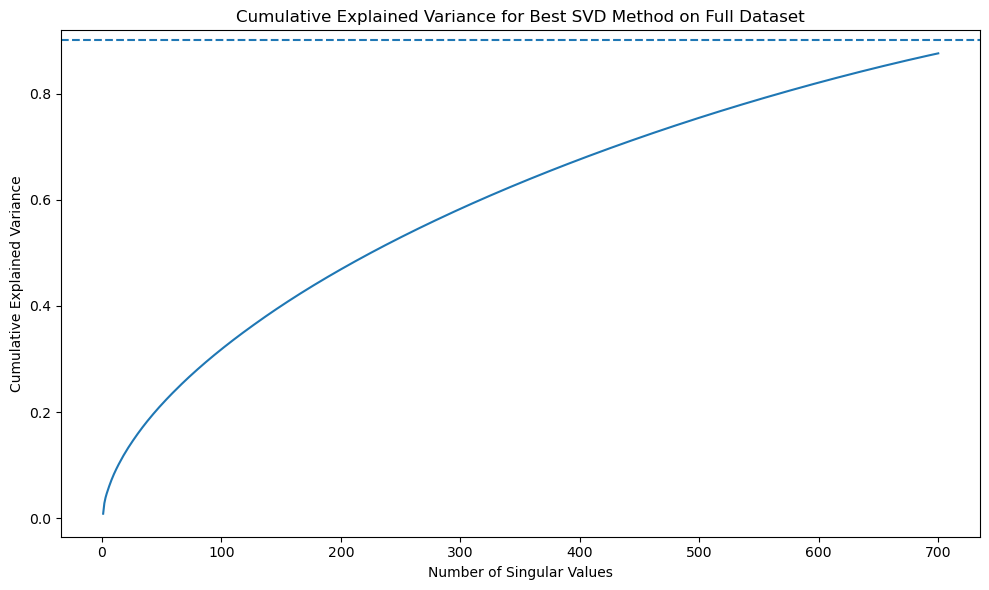

In [17]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(full_cumvar) + 1),
    full_cumvar
)

plt.axhline(0.90, linestyle="--")

plt.title("Cumulative Explained Variance for Best SVD Method on Full Dataset")
plt.xlabel("Number of Singular Values")
plt.ylabel("Cumulative Explained Variance")
plt.tight_layout()
plt.show()

Store final best model objects

In [18]:
best_vectorizer = full_vectorizer
best_svd = full_svd
best_X_tfidf = full_X_tfidf
best_X_svd = full_X_svd
best_cumulative_variance = full_cumvar
best_text_column = best_sampled_setting["text_column"]

print("Final best text column:", best_text_column)
print("Final full dataset result:")
full_result

Final best text column: text_basic
Final full dataset result:


{'experiment': 'Basic + unigram + 1000 features applied to full dataset',
 'max_features': 1000,
 'min_df': 5,
 'ngram_range': '(1, 1)',
 'tfidf_rows': 15165,
 'tfidf_features': 1000,
 'components_tested': 700,
 'reached_90_percent': np.False_,
 'retained_svs': 700,
 'explained_variance_at_retained_svs': np.float64(0.8756452844970647),
 'max_explained_variance_tested': np.float64(0.8756452844970647)}

Create TF-IDF dataframe for final model

In [19]:
best_tfidf_df = pd.DataFrame.sparse.from_spmatrix(
    best_X_tfidf,
    columns=best_vectorizer.get_feature_names_out()
)

best_tfidf_df.head()

,abilities,ability,able,according,achieve,acquire,action,actions,active,ad,...,workers,working,world,worlds,worth,written,year,years,yellow,young
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0.524832,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0.075985,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [20]:
#optional with titles
best_tfidf_df_with_titles = pd.concat(
    [
        combined_df[["title", "type"]].reset_index(drop=True),
        best_tfidf_df.reset_index(drop=True)
    ],
    axis=1
)

best_tfidf_df_with_titles.head()

,title,type,abilities,ability,able,according,achieve,acquire,action,actions,...,workers,working,world,worlds,worth,written,year,years,yellow,young
0,The Strange,TTRPG,0,0,0,0,0,0,0,0,...,0,0,0,0.524832,0,0,0,0,0,0
1,InSpectres,TTRPG,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Dungeons & Dragons Expert Set,TTRPG,0,0,0.075985,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,The Character Compendium,TTRPG,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,The Elves of Alfheim,TTRPG,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Create SVD semantic vectors dataframe

In [21]:
best_svd_df = pd.DataFrame(
    best_X_svd,
    columns=[f"SV {i+1}" for i in range(best_X_svd.shape[1])]
)

best_svd_df_with_titles = pd.concat(
    [
        combined_df[["title", "type"]].reset_index(drop=True),
        best_svd_df.reset_index(drop=True)
    ],
    axis=1
)

best_svd_df_with_titles.head()

,title,type,SV 1,SV 2,SV 3,SV 4,SV 5,SV 6,SV 7,SV 8,...,SV 691,SV 692,SV 693,SV 694,SV 695,SV 696,SV 697,SV 698,SV 699,SV 700
0,The Strange,TTRPG,0.092444,-0.103251,0.020984,0.078217,-0.048251,0.061596,0.037807,-0.027467,...,-0.022434,-0.003580,0.022851,-0.015315,-0.034097,-0.007887,0.022685,0.020289,0.013106,0.006945
1,InSpectres,TTRPG,0.213402,-0.054027,-0.046564,-0.106684,-0.037317,-0.003505,0.063376,-0.061883,...,-0.002555,0.030003,0.012549,0.024078,-0.015464,0.037126,-0.006230,0.021948,0.005060,-0.001548
2,Dungeons & Dragons Expert Set,TTRPG,0.228610,-0.191555,0.034745,-0.082704,0.206677,0.111006,-0.040694,-0.008795,...,0.012655,0.005422,-0.025298,-0.012158,-0.014622,0.006377,-0.005793,0.009504,0.017925,0.008208
3,The Character Compendium,TTRPG,0.176503,-0.224457,0.108311,-0.114661,0.160533,-0.170817,0.049321,0.029866,...,0.005900,-0.010895,-0.033485,-0.001263,0.001031,0.001457,-0.031052,0.007685,0.017659,-0.016500
4,The Elves of Alfheim,TTRPG,0.155758,-0.098401,0.014793,0.053541,-0.019214,-0.021952,-0.000509,0.008353,...,-0.017410,-0.007662,-0.003881,0.011258,0.001340,-0.017685,0.011742,-0.023860,-0.006026,0.017220


In [22]:
# IR search function

def search_games(query, text_preprocessor, vectorizer, svd, game_vectors, df, top_n=10):
    """
    Search for games similar to a user query using TF-IDF + SVD vectors.
    """

    clean_query = text_preprocessor(query)

    query_tfidf = vectorizer.transform([clean_query])
    query_svd = svd.transform(query_tfidf)

    similarities = cosine_similarity(query_svd, game_vectors).flatten()

    results = df[[
        "title",
        "type",
        "description",
        "average_score",
        "number_of_reviews"
    ]].copy()

    results["similarity"] = similarities

    return results.sort_values("similarity", ascending=False).head(top_n)

In [23]:
# Map final preprocessor

preprocessor_map = {
    "text_basic": preprocess_basic,
    "text_no_short": preprocess_no_short_words,
    "text_custom_stopwords": preprocess_remove_game_words
}

best_preprocessor = preprocessor_map[best_text_column]

print("Best preprocessor:", best_text_column)

Best preprocessor: text_basic


test IR queries

In [24]:
search_games(
    query="fantasy adventure with magic dragons and quests",
    text_preprocessor=best_preprocessor,
    vectorizer=best_vectorizer,
    svd=best_svd,
    game_vectors=best_X_svd,
    df=combined_df,
    top_n=10
)

,title,type,description,average_score,number_of_reviews,similarity
3316,Fantasy Hero 4th Edition,TTRPG,Publisher's description: Fantasy comes to the ...,6.80769,13.0,0.522653
4861,A Magical Medley (Fudge),TTRPG,A Magical Medley is a magic-rich supplement fo...,7.83333,6.0,0.514093
2908,Dragon Keep,TTRPG,From the back cover: The good dragons of Krynn...,6.20000,5.0,0.498409
1090,Adventuring Party 2013,TTRPG,Figure Set for Adventure Gaming From the back ...,0.00000,0.0,0.495473
228,Dungeons & Dragons Basic Rulebook (Second Edit...,TTRPG,From the back of the book: DUNGEONS & DRAGONS ...,7.99107,28.0,0.493874
3145,The Art of the Advanced Dungeons & Dragons Fan...,TTRPG,The Art of the Advanced Dungeons & Dragons Fan...,0.00000,0.0,0.481204
1123,Fantasy Wargaming: The Highest Level of All,TTRPG,From the dust jacket: Fantasy Wargaming - Comp...,4.10000,46.0,0.475133
925,Dungeons & Dragons Basic Set (Second Edition),TTRPG,"From the back of the box: ""Fire and smoke surr...",8.09080,250.0,0.468267
5519,Dragonlance Miniature Reprints: Volume 1 – DL1...,TTRPG,"User summaryThis is a box containing eight 4"" ...",7.00000,2.0,0.467462
5187,Dungeons & Dragons Adventure Game (Silver Anni...,TTRPG,From the Back of the Box: The classic game of ...,6.78571,7.0,0.445253


In [25]:
search_games(
    query="horror mystery investigation supernatural monsters",
    text_preprocessor=best_preprocessor,
    vectorizer=best_vectorizer,
    svd=best_svd,
    game_vectors=best_X_svd,
    df=combined_df,
    top_n=10
)

,title,type,description,average_score,number_of_reviews,similarity
5260,Nightmares of Mine,TTRPG,[Back cover] Horror has been with us for as lo...,8.73333,12.0,0.533453
6267,Mansions of Madness: Second Edition,Board Game,Mansions of Madness: Second Edition is a fully...,8.02000,NaN,0.513126
3059,Blood Brothers,TTRPG,A humourous collection of non-Mythos horror ad...,6.79429,35.0,0.433306
3624,Il Gioco di Ruolo di Dylan Dog,TTRPG,Information from Back Cover IL PRIMO GIOCO DI ...,6.66667,6.0,0.421866
6252,Eldritch Horror,Board Game,"Across the globe, ancient evil is stirring. No...",7.78000,NaN,0.414353
6467,Mansions of Madness,Board Game,Description from the publisher:&#10;&#10;Horri...,7.29000,NaN,0.402664
95,Unknown Armies,TTRPG,From the cover: A Roleplaying Game of Transcen...,7.73404,47.0,0.393167
7377,City of Horror,Board Game,City of Horror is a backstabbing survival-horr...,6.70000,NaN,0.382167
689,The Between (Preview Edition),TTRPG,(From DTRPG:) The Between is a tabletop rolepl...,9.08333,12.0,0.369195
2221,Halls of Horror: Gothic Floor Plans,TTRPG,From the back of the box: On the surface it se...,7.60000,5.0,0.368137


In [26]:
search_games(
    query="science fiction space exploration cyberpunk future technology",
    text_preprocessor=best_preprocessor,
    vectorizer=best_vectorizer,
    svd=best_svd,
    game_vectors=best_X_svd,
    df=combined_df,
    top_n=10
)

,title,type,description,average_score,number_of_reviews,similarity
984,Space Opera,TTRPG,Space Opera is a science-fiction role-playing ...,6.29200,25.0,0.592675
3268,Buck Rogers Boxed Set XXVc,TTRPG,Buck Rogers and the forces of the New Earth Or...,7.61765,17.0,0.567552
173,Genesys Core Rulebook,TTRPG,Description from the publisher: Face down a dr...,8.09615,52.0,0.516001
4114,Tradition Book: Sons of Ether (1st Edition),TTRPG,"""Gentlemen, I give you the amazing Electrodyna...",6.91176,17.0,0.511235
3367,GURPS Aliens,TTRPG,"From the cover: ""Nonhuman Races for Science Fi...",6.40909,11.0,0.495579
4961,High Tech and Low Life,TTRPG,Blurb from back cover: The world of Shadowrun ...,6.18182,11.0,0.464648
3026,GURPS Space (Second Edition),TTRPG,"Subtitle: ""Roleplaying in the Worlds of Tomorr...",7.04545,33.0,0.463210
982,The Astrogators Chartbook,TTRPG,"From the cover: ""Complete science fiction mapp...",6.28571,7.0,0.457518
4011,GURPS Atomic Horror,TTRPG,"""Science Runs Amok in B-Movie Adventures!""",7.76923,13.0,0.453080
5095,Trinity Technology Manual,TTRPG,THE FUTURE IS AT YOUR FINGERTIPS It's the 22nd...,7.31250,8.0,0.449173


In [27]:
search_games(
    query="strategy war civilization resource management combat",
    text_preprocessor=best_preprocessor,
    vectorizer=best_vectorizer,
    svd=best_svd,
    game_vectors=best_X_svd,
    df=combined_df,
    top_n=10
)

,title,type,description,average_score,number_of_reviews,similarity
6412,Sid Meier's Civilization: The Board Game,Board Game,Please note: this entry covers the 2010 releas...,7.40,NaN,0.450564
7753,Age of Renaissance,Board Game,A game that is often described as a semi-seque...,7.10,NaN,0.391446
8421,Age of Civilization,Board Game,"In the Age of Civilization, you must lead your...",7.13,NaN,0.387288
9097,Mega Civilization,Board Game,Description from the publisher:&#10;&#10;Mega ...,8.24,NaN,0.368430
11829,Nile,Board Game,Nile the card game consists of 92 cards. There...,6.10,NaN,0.358986
7247,Vikings Gone Wild,Board Game,Each turn in Vikings Gone Wild &mdash; a deck-...,7.18,NaN,0.351484
6708,Civilization,Board Game,Civilization is a game of skill for 2 to 7 pla...,7.50,NaN,0.350835
7475,Sid Meier's Civilization: The Boardgame,Board Game,This entry covers the 2002 release of Sid Meie...,5.60,NaN,0.341029
11726,Tribes: Early Civilization,Board Game,Guide your tribe in its struggles to survive a...,6.52,NaN,0.333460
14534,"Outreach: The Conquest of the Galaxy, 3000AD",Board Game,"Simulates civilization development, intra-gala...",6.56,NaN,0.329612


In [28]:
summary_table = pd.concat(
    [
        results_df.assign(stage="sampled_experiment"),
        pd.DataFrame([full_result]).assign(stage="full_dataset_best_method")
    ],
    ignore_index=True
)

summary_table

,experiment,max_features,min_df,ngram_range,tfidf_rows,tfidf_features,components_tested,reached_90_percent,retained_svs,explained_variance_at_retained_svs,max_explained_variance_tested,stage
0,Basic + unigram + 1000 features,1000,5,"(1, 1)",5000,1000,300,False,300,0.611578,0.611578,sampled_experiment
1,Basic + unigram + 3000 features,3000,5,"(1, 1)",5000,3000,300,False,300,0.407694,0.407694,sampled_experiment
2,No short words + unigram + 3000 features,3000,5,"(1, 1)",5000,3000,300,False,300,0.408634,0.408634,sampled_experiment
3,Custom stopwords + unigram + 3000 features,3000,5,"(1, 1)",5000,3000,300,False,300,0.394327,0.394327,sampled_experiment
4,Basic + unigram/bigram + 3000 features,3000,5,"(1, 2)",5000,3000,300,False,300,0.413528,0.413528,sampled_experiment
5,Basic + unigram + 1000 features applied to ful...,1000,5,"(1, 1)",15165,1000,700,False,700,0.875645,0.875645,full_dataset_best_method


## Findings

After testing multiple TF-IDF + SVD setups on a 5,000-row sample, the highest-performing setup was Basic preprocessing + unigram TF-IDF + 1000 features. This setup preserved the most explained variance among the sampled experiments. I then applied this setup to the full merged dataset of 15,165 games. With 700 retained singular values, the model preserved about 87.56% explained variance. Although it did not fully reach 90%, it was close while still being manageable to run.

For the IR test, the sample queries returned mostly relevant results based on their themes, such as fantasy, horror, science fiction, and strategy/civilization.